![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [151]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [3]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [4]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

In [67]:
# Descripción general de los datos numéricos
bikes.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132,11.541613
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454,6.915838
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000,6.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000,12.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000,18.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000,23.000000


<Figure size 1000x600 with 0 Axes>

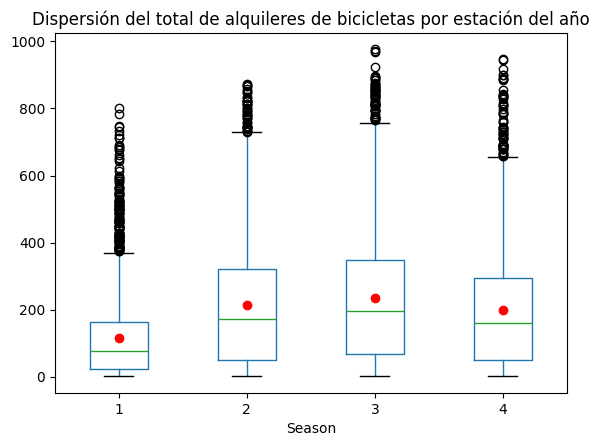

In [21]:
# Total alquileres agrupados por estación del año
plt.figure(figsize=(10,6))
boxes = bikes.boxplot(column='total', by='season', grid=False)
boxes.set_xlabel('Season')
#incluir marcador para la media de cada estación
means = bikes.groupby('season').total.mean()
for i, mean in enumerate(means):
    plt.plot(i+1, mean, marker='o', color='red')
plt.title('Dispersión del total de alquileres de bicicletas por estación del año')
plt.suptitle('')
plt.show()

In [26]:
# Tabla resumen percentiles por estación del año
bikes.groupby('season').total.describe(percentiles=[0.25, 0.5, 0.75])

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2686.0,116.343261,125.273974,1.0,24.0,78.0,164.0,801.0
2,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0
3,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0
4,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0


In [5]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

<Figure size 2000x1600 with 0 Axes>

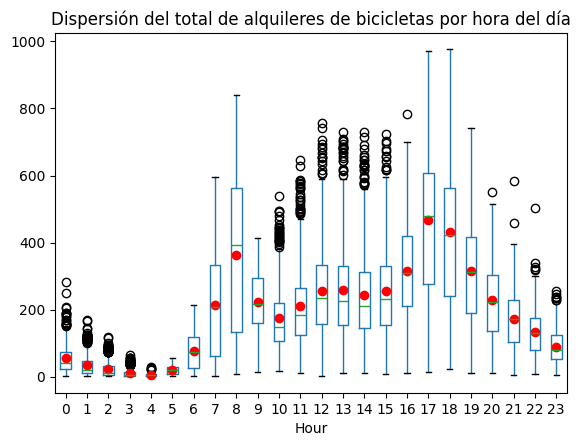

In [25]:
# Total alquileres agrupados por hora del día
plt.figure(figsize=(20,16))
boxes = bikes.boxplot(column='total', by='hour', grid=False)
boxes.set_xlabel('Hour')
#incluir un marcador para la media de cada hora
means = bikes.groupby('hour').total.mean()
for i, mean in enumerate(means):
    plt.plot(i+1, mean, marker='o', color='red')
plt.title('Dispersión del total de alquileres de bicicletas por hora del día')
plt.suptitle('')
plt.show()

In [27]:
# Tabla resumen percentiles total alquileres por hora del día
bikes.groupby('hour').total.describe(percentiles=[0.25, 0.5, 0.75])

,count,mean,std,min,25%,50%,75%,max
hour,,,,,,,,
0,455.0,55.138462,43.620012,2.0,24.00,41.0,74.50,283.0
1,454.0,33.859031,34.112105,1.0,11.00,19.0,46.00,168.0
2,448.0,22.899554,26.110267,1.0,5.00,11.0,32.00,119.0
3,433.0,11.757506,12.666442,1.0,3.00,6.0,15.00,66.0
4,442.0,6.407240,4.217633,1.0,3.00,6.0,9.00,28.0
5,452.0,19.767699,12.784293,1.0,8.00,19.0,29.00,57.0
6,455.0,76.259341,54.745333,1.0,24.50,75.0,118.00,213.0
7,455.0,213.116484,159.207044,1.0,63.00,208.0,334.00,596.0
8,455.0,362.769231,231.723065,8.0,133.50,392.0,563.50,839.0


## Análisis de datos

A partir de los gráficos de cajas y bigotes, se observa que la estación 3 tiene un mayor volumen de alquileres frente a las demás estaciones ubicando el 50% central de sus datos entre 68 y 347 alquileres, llegando a tener un máximo de 977 alquileres. Por otro lado, la hora del día evidencia que las horas 8 y 17 tienen la mayor cantidad de alquileres en el día y tiene sentido para las personas que buscan este medio de transporte para ir a trabajar. En horas de la madrugrada hay muy baja utilización teniendo menos de 100 alquileres en las primeras 5 horas del día. Se observa una mayor dispersión de datos en la hora 8 frente a las demás, donde el 50% de sus datos centrales están entre 133 y 563 alquileres.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

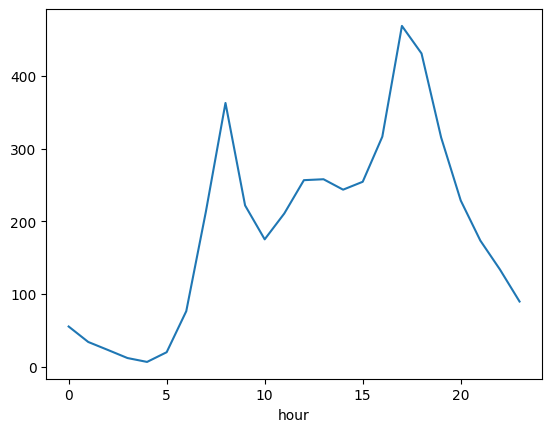

In [28]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

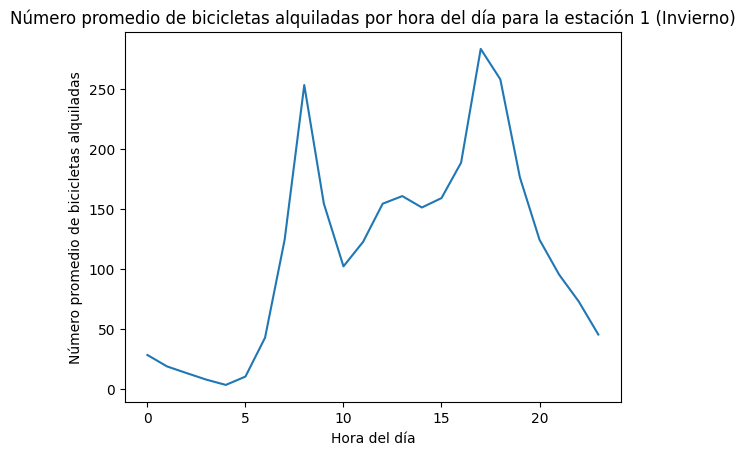

In [29]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
# Gráfica del número de bicicletas alquiladas por hora del día para la estación 1 (Invierno)
bikes[bikes.season==1].groupby('hour').total.mean().plot()
plt.title('Número promedio de bicicletas alquiladas por hora del día para la estación 1 (Invierno)')
plt.xlabel('Hora del día')
plt.ylabel('Número promedio de bicicletas alquiladas')
plt.show()

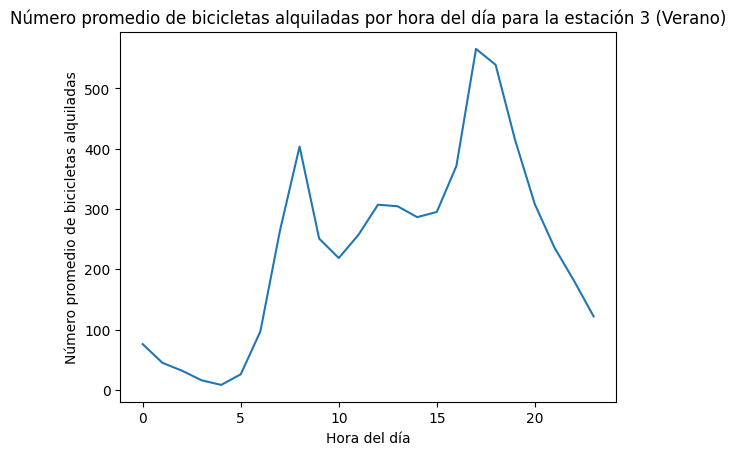

In [30]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
# Gráfica del número de bicicletas alquiladas por hora del día para la estación 3 (Verano)
bikes[bikes.season==3].groupby('hour').total.mean().plot()
plt.title('Número promedio de bicicletas alquiladas por hora del día para la estación 3 (Verano)')
plt.xlabel('Hora del día')
plt.ylabel('Número promedio de bicicletas alquiladas')
plt.show()

## Observaciones de la hora del día por estación

Se observa que las 3 gráficas anteriores tienen un patrón similar en la hora que se alquilan bicicletas con un pico de alquileres promedio en la hora 8 y 17. Sin embargo, el promedio de alquileres es mayor en la estación de verano, siendo mayor a 500 alquileres, mientras que en invierno no logra llegar a los 300 alquileres, y en conjunto con todas las estaciones se encuentra por debajo de 500 alquileres

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [ ]:
# Celda 3
# Selección de las variables predictoras y la variable respuesta

Y_total = bikes['total']
X_total = bikes[['season', 'hour']]

# convertir las variables categóricas en variables dummy
X_total = pd.get_dummies(X_total, columns=['season'], drop_first=True, dtype=int)

# Partiremos la base de datos en una sección de train y otra de test
XTrain, XTest, yTrain, yTest = train_test_split(X_total, Y_total, test_size=0.33, random_state=0)

In [97]:
# Definición del modelo de regresión lineal, entrenamiento y evaluación
lr = LinearRegression()
lr.fit(XTrain, yTrain)
# Cálculo del R^2 en test
print('R^2 en test:', lr.score(XTest, yTest))
# Cálculo del error cuadrático medio (RMSE) en test
yPred_lr = lr.predict(XTest)
rmse_lr = np.sqrt(np.mean((yTest - yPred_lr)**2))
print('RMSE en test:', rmse_lr)
# Calcular el MAE en test
mae_lr = np.mean(np.abs(yTest - yPred_lr))
print('MAE en test:', mae_lr)
# Calcular el mape en test
mape_lr = np.mean(np.abs((yTest - yPred_lr) / yTest)) * 100
print('MAPE en test:', mape_lr)

R^2 en test: 0.21517712032533343
RMSE en test: 160.13875579927014
MAE en test: 118.94195942411864
MAPE en test: 366.8087647892259


## Limitaciones Modelo Lineal

Entre las limitaciones se encuentra que el modelo busca predecir el fenómeno a partir de una línea recta, lo cual omite las variaciones observadas que tiene el alquiler frente a las variables de la estación y hora del día. Es decir, los picos y valles que se observan en las horas del día, el modelo no logra interpretarlo correctamente.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [79]:
# Celda 4

# Definición del MSE como función de evaluación para el árbol de decisión
def mse(y):
    if y.shape[0] == 0:
        return 0
    # La varianza es equivalente al MSE si usamos la media como predictor
    return np.var(y)

In [80]:
# Definición de la función para calcular la ganancia de una división dada una variable predictora y un punto de corte
def mse_gain(X_col, y, split):
    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]
    
    n = y.shape[0]
    n_l, n_r = y_l.shape[0], y_r.shape[0]
    
    if n_l == 0 or n_r == 0:
        return 0
    
    # Reducción de varianza (Ganancia)
    gain = mse(y) - (n_l / n * mse(y_l) + n_r / n * mse(y_r))
    return gain

In [81]:
# Definición de la función best_split para calcular cuál es la mejor variable y punto de corte para hacer el corte del árbol
def best_split_regression(X, y, num_pct=10):
    features = range(X.shape[1])
    
    best_split = [0, 0, -float('inf')] 
    
    for j in features:
        splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / (num_pct + 1)).tolist())
        splits = np.unique(splits)[1:]
        
        for split in splits:
            gain = mse_gain(X.iloc[:, j], y, split)
            
            if gain > best_split[2]:
                best_split = [j, split, gain]
    
    return best_split

In [82]:
# Definición de la función tree_grow para hacer un crecimiento recursivo del árbol
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    
    # Si solo es una observación
    if X.shape[0] == 1:
        tree = dict(y_pred=y.iloc[:1].values[0], y_prob=0.5, level=level, split=-1, n_samples=1, gain=0)
        return tree
    
    # Calcular la mejor división
    j, split, gain = best_split_regression(X, y, num_pct)
    
    # Guardar el árbol y estimar la predicción
    y_pred = y.mean()
    
    tree = dict(y_pred=y_pred, level=level, split=-1, n_samples=X.shape[0], gain=gain)
    # Revisar el criterio de parada 
    if gain < min_gain:
        return tree
    if max_depth is not None:
        if level >= max_depth:
            return tree   
    
    # Continuar creando la partición
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    tree['split'] = [j, split]

    # Siguiente iteración para cada partición
    
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    
    return tree

In [83]:
# Aplicación de la función tree_grow para construir el árbol de decisión sobre el conjunto de Train
tree = tree_grow(XTrain, yTrain, level=0, min_gain=0.001, max_depth=10, num_pct=10)
tree

{'y_pred': np.float64(189.627313862608),
 'level': 0,
 'split': [0, np.float64(8.0)],
 'n_samples': 7293,
 'gain': np.float64(9234.192546258972),
 'sl': {'y_pred': np.float64(53.85456039441249),
  'level': 1,
  'split': [0, np.float64(7.0)],
  'n_samples': 2434,
  'gain': np.float64(3347.73634976643),
  'sl': {'y_pred': np.float64(32.450256889304065),
   'level': 2,
   'split': [0, np.float64(6.0)],
   'n_samples': 2141,
   'gain': np.float64(301.410353371846),
   'sl': {'y_pred': np.float64(25.25287356321839),
    'level': 3,
    'split': [0, np.float64(2.0)],
    'n_samples': 1827,
    'gain': np.float64(199.48629238477474),
    'sl': {'y_pred': np.float64(44.8876404494382),
     'level': 4,
     'split': [0, np.float64(1.0)],
     'n_samples': 623,
     'gain': np.float64(110.39823203012566),
     'sl': {'y_pred': np.float64(55.41157556270097),
      'level': 5,
      'split': [2, np.float64(1.0)],
      'n_samples': 311,
      'gain': np.float64(130.8579548414143),
      'sl': {'y_

In [ ]:
# Definición de la función tree_predict_regression para hacer predicciones según las variables predictoras y el arbol construido

def tree_predict_regression(X, tree):
    predicted = np.ones(X.shape[0])

    if tree['split'] == -1:
        return predicted * tree['y_pred']
    
    j, split = tree['split']
    filter_l = (X.iloc[:, j] < split)
    
    # Aplicar recursión en las ramas
    predicted[filter_l] = tree_predict_regression(X.loc[filter_l], tree['sl'])
    predicted[~filter_l] = tree_predict_regression(X.loc[~filter_l], tree['sr'])
    
    return predicted

In [85]:
# Ejecución de función tree_predict
tree_predict_regression(XTest, tree)

array([ 96.68656716, 356.1125    , 174.11538462, ..., 286.49367089,
        88.11267606, 275.93670886], shape=(3593,))

In [98]:
# Calcular el RMSE en test para el árbol de decisión
yPred_tree = tree_predict_regression(XTest, tree)
rmse_tree = np.sqrt(((yTest - yPred_tree) ** 2).mean())
print('RMSE en test para el árbol de decisión:', rmse_tree)
# Calcular el MAE en test para el árbol de decisión
mae_tree = np.mean(np.abs(yTest - yPred_tree))
print('MAE en test para el árbol de decisión:', mae_tree)
# Calcular el mape en test para el árbol de decisión
mape_tree = np.mean(np.abs((yTest - yPred_tree) / yTest)) * 100
print('MAPE en test para el árbol de decisión:', mape_tree)

RMSE en test para el árbol de decisión: 115.73032667446998
MAE en test para el árbol de decisión: 78.31480101935522
MAPE en test para el árbol de decisión: 102.96829960389233


In [90]:
# Calcular número de nodos finales del árbol de decisión
def count_leaves(tree):
    if tree['split'] == -1:
        return 1
    else:
        return count_leaves(tree['sl']) + count_leaves(tree['sr'])

count_leaves(tree)

94

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [103]:
# Celda 5

# Lista de valores para calibrar el criterio de parada de máxima profundidad (max_depth)
max_depth_range = range(1, 21)

# Lista para guardar los valores del RMSE para cada valor de máxima profundidad (max_depth)
rmse_scores = []

# Loop para obtener el desempeño del modelo de acuerdo con la máxima profundidad
for depth in max_depth_range:
    # Definición del árbol de decisión usando DecisionTreeRegressor de la libreria sklearn
    clf = DecisionTreeRegressor(max_depth=depth, random_state=1)
    rmse_scores.append(cross_val_score(clf, XTrain, yTrain, cv=10, scoring='neg_root_mean_squared_error').mean())


Text(0, 0.5, 'RMSE')

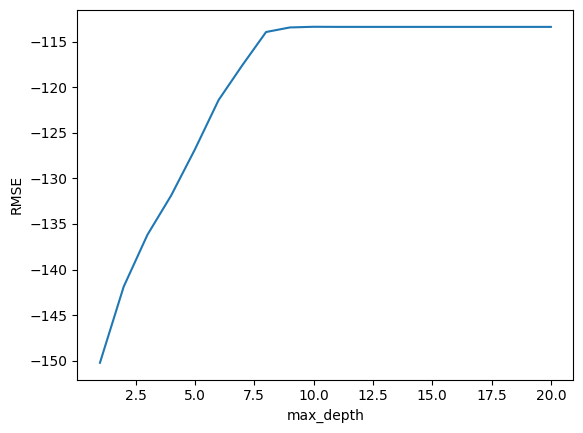

In [104]:
# Gráfica max_depth versus RMSE (error del modelo)
plt.plot(max_depth_range, rmse_scores)
plt.xlabel('max_depth')
plt.ylabel('RMSE')

In [108]:
# Mejor RMSE (desempeño del modelo) y su correspondiente max_depth
sorted(zip(rmse_scores, max_depth_range))[::-1][0]

(np.float64(-113.38037242056912), 10)

In [111]:
# max_depth=10 fue el mejor, se ajusta un árbol usando este valor 
clf = DecisionTreeRegressor(max_depth=10, random_state=1)
clf.fit(XTrain, yTrain)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf

In [112]:
# Validación del modelo con max_depth=10 en test
yPred_tree = clf.predict(XTest)
# RMSE en test para el árbol de decisión
rmse_tree = np.sqrt(((yTest - yPred_tree) ** 2).mean())
print('RMSE en test para el árbol de decisión con max_depth=10:', rmse_tree)
# MAE en test para el árbol de decisión
mae_tree = np.mean(np.abs(yTest - yPred_tree))
print('MAE en test para el árbol de decisión con max_depth=10:', mae_tree)
# MAPE en test para el árbol de decisión
mape_tree = np.mean(np.abs((yTest - yPred_tree) / yTest)) * 100
print('MAPE en test para el árbol de decisión con max_depth=10:', mape_tree)

RMSE en test para el árbol de decisión con max_depth=10: 115.73032667446998
MAE en test para el árbol de decisión con max_depth=10: 78.31480101935522
MAPE en test para el árbol de decisión con max_depth=10: 102.96829960389233


## Conclusiones

Según el desempeño del RMSE, se observa que el modelo de árbol de decisión con calibración de su profundidad, es superior al modelo de regresión lineal del punto 3 en 45 alquileres. Esto implica mayor confianza en el modelo utilizando árboles de decisión. No se concluye sobre el R2 del modelo de árbol de decisión al no ser un modelo lineal. Es posible mejorar el desempeño utilizando ensambles que utilizan árboles de decisión como Random Forest o XGBoost. Se observa que el árbol creado de forma manual tiene exactamente los mismos resultados que el arbol creado con la librería sklearn.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [113]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [114]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [115]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [118]:
# Celda 6

# Construcción del árbol de decisión

# Lista de valores para calibrar el criterio de parada de máxima profundidad (max_depth)
max_depth_range_clf = range(1, 50)

# Lista para guardar los valores del accuracy para cada valor de máxima profundidad (max_depth)
accuracy_scores = []

# Importación de modelos de sklearn 
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

# Loop para obtener el desempeño del modelo de acuerdo con la máxima profundidad
for depth in max_depth_range_clf:
    # Definición del árbol de decisión usando DecisionTreeClassifier de la libreria sklearn
    clf_arbol = DecisionTreeClassifier(max_depth=depth, random_state=1)
    accuracy_scores.append(cross_val_score(clf_arbol, X_train, y_train, cv=10, scoring='accuracy').mean())

Text(0, 0.5, 'Accuracy')

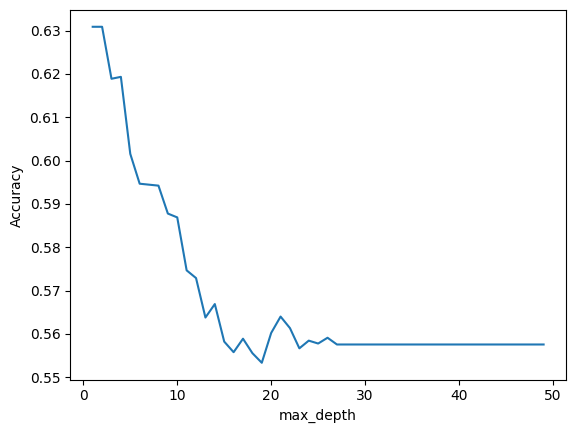

In [119]:
# Gráfica max_depth versus Accuracy (error del modelo)
plt.plot(max_depth_range_clf, accuracy_scores)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')

In [120]:
# Mejor accuracy (desempeño del modelo) y su correspondiente max_depth
sorted(zip(accuracy_scores, max_depth_range_clf))[::-1][0]

(np.float64(0.6308888888888888), 2)

In [121]:
# max_depth=2 fue el mejor, se ajusta un árbol usando este valor 
clf = DecisionTreeClassifier(max_depth=2, random_state=1)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

In [123]:
# Evaluación del modelo de árbol de decisión con max_depth=2 en test
y_pred_clf = clf.predict(X_test)
# Accuracy en test para el árbol de decisión
accuracy_clf = np.mean(y_test == y_pred_clf)
print('Accuracy en test para el árbol de decisión con max_depth=2:', accuracy_clf)
# f1-score en test para el árbol de decisión
f1_clf = f1_score(y_test, y_pred_clf)
print('f1-score en test para el árbol de decisión con max_depth=2:', f1_clf)

Accuracy en test para el árbol de decisión con max_depth=2: 0.6453333333333333
f1-score en test para el árbol de decisión con max_depth=2: 0.6448598130841121


In [124]:
# Construcción del modelo regresión logística
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000, random_state=1)
logreg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [128]:
# Evaluación del modelo de regresión logística en test
y_pred_logreg = logreg.predict(X_test)
# Accuracy en test para el modelo de regresión logística
accuracy_logreg = np.mean(y_test == y_pred_logreg)
print('Accuracy en test para el modelo de regresión logística:', accuracy_logreg)
# f1-score en test para el modelo de regresión logística
f1_logreg = f1_score(y_test, y_pred_logreg)
print('f1-score en test para el modelo de regresión logística:', f1_logreg)

Accuracy en test para el modelo de regresión logística: 0.6153333333333333
f1-score en test para el modelo de regresión logística: 0.6039807824296499


### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [132]:
# Celda 7
# Votación mayoritaria para ensamble de 300 predicciones

# Creación de 300 muestras de bootstrap
n_estimators = 300
np.random.seed(123)

n_samples = X_train.shape[0]
samples = [np.random.choice(a=n_samples, size=n_samples, replace=True) for _ in range(n_estimators)]


In [153]:
# Entrenamiento de 300 modelos con las 300 muestras boostrap en 3 grupos de 100 modelos cada uno
# cada modelo es un árbol de decisión con max_depth=10 para los primeros 100 modelos
# min_samples_leaf=5 para los siguientes 100 modelos
# regresiones logísticas para los últimos 100 modelos

np.random.seed(123) 
seeds = np.random.randint(1, 10000, size=n_estimators)

models = {}
for i in range(n_estimators):
    if i < 100:
        models[i] = DecisionTreeClassifier(max_features="sqrt", max_depth=10, random_state=seeds[i])
        models[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])
    elif i < 200:
        models[i] = DecisionTreeClassifier(max_features="sqrt", max_depth=None, random_state=seeds[i], min_samples_leaf=5)
        models[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])
    else:
        models[i] = LogisticRegression(max_iter=1000, random_state=seeds[i])
        models[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])

In [154]:
# Listas para guardar las métricas de cada modelo individual
accuracy_scores_vm = []
f1_scores_vm = []

# Matriz para guardar las predicciones (Filas = observaciones de test, Columnas = modelos)
y_pred_df = pd.DataFrame(index=X_test.index, columns=list(range(n_estimators)))

for i in range(n_estimators):

    y_pred = models[i].predict(X_test)
    y_pred_df[i] = y_pred
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores_vm.append(accuracy)
    f1 = f1_score(y_test, y_pred)
    f1_scores_vm.append(f1)
    
y_pred_df.head()

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
1483,1,1,1,1,0,0,1,1,1,0,...,1,1,1,1,1,1,1,1,1,1
2185,1,0,1,1,1,0,1,0,1,1,...,1,1,1,1,1,1,1,1,1,1
2520,1,0,1,1,1,1,0,1,0,0,...,1,1,1,1,1,1,1,1,1,1
3721,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
3727,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [168]:
# Accuracy para las primeras 100 predicciones (árboles de decisión con max_depth=10)
accuracy_m1 = np.mean(accuracy_scores_vm[:100])
print('Accuracy promedio para los primeros 100 modelos (árboles de decisión con max_depth=10):', accuracy_m1)
# f1-score para las primeras 100 predicciones (árboles de decisión con max_depth=10)
f1_m1 = np.mean(f1_scores_vm[:100])
print('f1-score promedio para los primeros 100 modelos (árboles de decisión con max_depth=10):', f1_m1)

Accuracy promedio para los primeros 100 modelos (árboles de decisión con max_depth=10): 0.5913466666666668
f1-score promedio para los primeros 100 modelos (árboles de decisión con max_depth=10): 0.5873165644638418


In [169]:
# Accuracy para las segundas 100 predicciones (árboles de decisión con min_samples_leaf=5)
accuracy_m2 = np.mean(accuracy_scores_vm[100:200])
print('Accuracy promedio para los siguientes 100 modelos (árboles de decisión con min_samples_leaf=5):', accuracy_m2)
# f1-score para las segundas 100 predicciones (árboles de decisión con min_samples_leaf=5)
f1_m2 = np.mean(f1_scores_vm[100:200])
print('f1-score promedio para los siguientes 100 modelos (árboles de decisión con min_samples_leaf=5):', f1_m2)

Accuracy promedio para los siguientes 100 modelos (árboles de decisión con min_samples_leaf=5): 0.5683399999999998
f1-score promedio para los siguientes 100 modelos (árboles de decisión con min_samples_leaf=5): 0.5620026313339114


In [171]:
# Accuracy para las ultimas 100 predicciones (regresiones logísticas)
accuracy_m3 = np.mean(accuracy_scores_vm[200:300])
print('Accuracy promedio para los últimos 100 modelos (regresiones logísticas):', accuracy_m3)
# f1-score para las últimas 100 predicciones (regresiones logísticas)
f1_m3 = np.mean(f1_scores_vm[200:300])
print('f1-score promedio para los últimos 100 modelos (regresiones logísticas):', f1_m3)

Accuracy promedio para los últimos 100 modelos (regresiones logísticas): 0.61358
f1-score promedio para los últimos 100 modelos (regresiones logísticas): 0.5983110348375871


In [185]:
# Votación mayoritaria
y_pred_vm = (y_pred_df.sum(axis=1) >= (n_estimators / 2)).astype(np.int64)

# Desempeño al hacer votación mayoritaria
f1_vm = metrics.f1_score(y_pred_vm, y_test)
print('F1-score para el modelo de votación mayoritaria:', f1_vm)

F1-score para el modelo de votación mayoritaria: 0.6212121212121212


In [186]:
# Desempeño al hacer votación mayoritaria
accuracy_vm = metrics.accuracy_score(y_pred_vm, y_test)
print('Accuracy para el modelo de votación mayoritaria:', accuracy_vm)

Accuracy para el modelo de votación mayoritaria: 0.6333333333333333


### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [174]:
# Celda 8

samples_oob = []
# Obtención de las observaciones fuera de la bolsa "out-of-bag" para cada muestra
for sample in samples:
    samples_oob.append(sorted(set(range(n_samples)) - set(sample)))

In [175]:
# Estimación de los errores OOB para cada clasificador
errors = np.zeros(n_estimators)

for i in range(n_estimators):
    y_pred_ = models[i].predict(X_train.iloc[samples_oob[i]])
    errors[i] = 1 - metrics.accuracy_score(y_train.iloc[samples_oob[i]], y_pred_)

Text(0.5, 1.0, 'OOB error of each model')

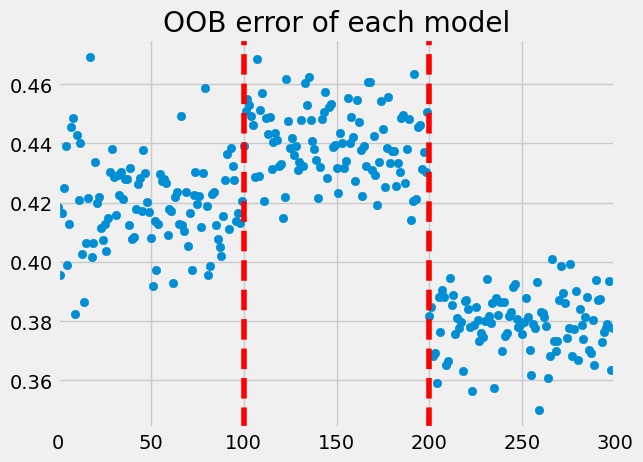

In [181]:
# Visualización de OOB para cada modelo
plt.style.use('fivethirtyeight')
plt.scatter(range(n_estimators), errors)
plt.xlim([0, n_estimators])
# linea vertical para separar los 3 grupos de modelos
plt.axvline(x=100, color='red', linestyle='--')
plt.axvline(x=200, color='red', linestyle='--')
plt.title('OOB error of each model')

In [178]:
# Obtención de los pesos alpha de cada modelo de acuerdo al error OOB
alpha = (1 - errors) / (1 - errors).sum()

In [179]:
# Ponderación de las predicciones con los pesos alpha
weighted_sum_1 = ((y_pred_df) * alpha).sum(axis=1)
weighted_sum_1.head(20)

1483    0.825553
2185    0.854338
2520    0.756092
3721    0.834960
3727    0.154086
4524    0.485301
234     0.080444
4735    0.223329
5839    0.379605
2939    0.729171
3053    0.793700
867     0.793205
276     0.768010
5798    0.131825
3512    0.835141
5789    0.096895
3198    0.725580
5908    0.887595
5718    0.242114
2687    0.125249
dtype: float64

In [187]:
# Desempeño al hacer votación ponderada
y_pred = (weighted_sum_1 >= 0.5).astype(np.int64)
f1_ponderada = metrics.f1_score(y_pred, y_test)
accuracy_ponderada = metrics.accuracy_score(y_pred, y_test)
print('F1-score para el modelo de votación ponderada:', f1_ponderada)
print('Accuracy para el modelo de votación ponderada:', accuracy_ponderada)

F1-score para el modelo de votación ponderada: 0.6180316586373021
Accuracy para el modelo de votación ponderada: 0.63


### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

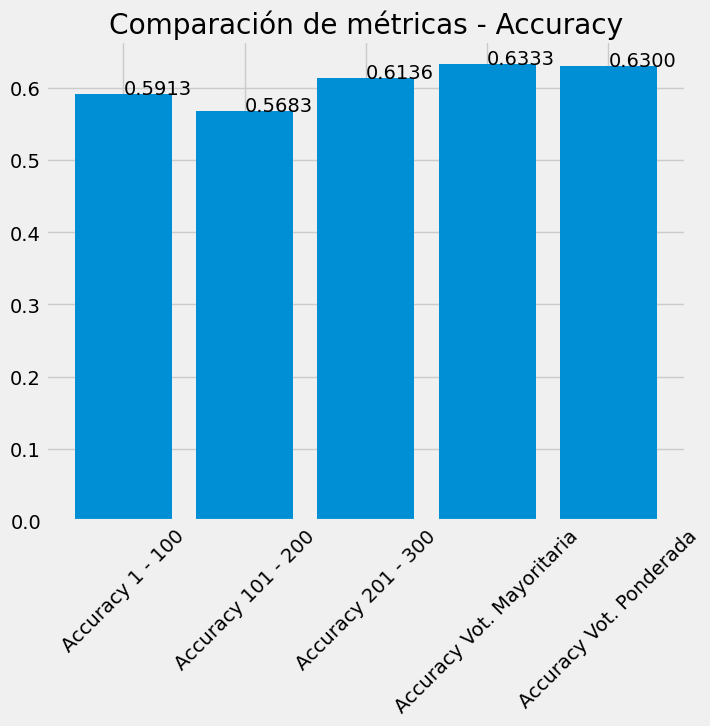

In [191]:
# Celda 9

# COMPARACIÓN DE MÉTRICAS

fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.set_title("Comparación de métricas - Accuracy")
ejeX = ['Accuracy 1 - 100', 'Accuracy 101 - 200','Accuracy 201 - 300', 'Accuracy Vot. Mayoritaria', 'Accuracy Vot. Ponderada']
ejeY = [accuracy_m1,accuracy_m2,accuracy_m3, accuracy_vm, accuracy_ponderada]
ax.bar(ejeX,ejeY)
def addlabels(x,y,plotP):
    for i in range(len(x)):
        plotP.text(i,y[i],f'{y[i]:.4f}')
addlabels(ejeX,ejeY,plt)
plt.xticks(rotation=45)
plt.show()

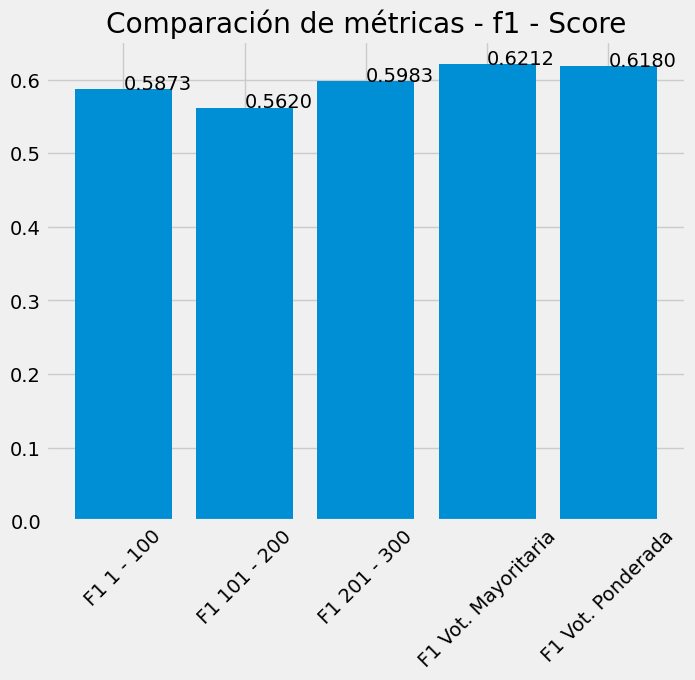

In [192]:
# COMPARACIÓN DE MÉTRICAS

fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.set_title("Comparación de métricas - f1 - Score")
ejeX = ['F1 1 - 100', 'F1 101 - 200','F1 201 - 300', 'F1 Vot. Mayoritaria', 'F1 Vot. Ponderada']
ejeY = [f1_m1,f1_m2,f1_m3, f1_vm, f1_ponderada]
ax.bar(ejeX,ejeY)
def addlabels(x,y,plotP):
    for i in range(len(x)):
        plotP.text(i,y[i],f'{y[i]:.4f}')
addlabels(ejeX,ejeY,plt)
plt.xticks(rotation=45)
plt.show()

# Conclusiones

A partir de los resultados obtenidos por los 300 modelos, se observa que los ensambles de votación mayoritaria y votación ponderada tienen un mejor desempeño que el resultado de las 100 muestras por separado. Adicionalmente, el mejor modelo en cuanto al accuracy y el f1-score es la votación mayoritaria seguido muy de cerca por el modelo de votación ponderada. Es probable que la votación mayoritaria tenga un problema de sesgo al tratar a todos los 'votos' por igual teniendo en cuenta que hay unas probabilidades más cercanas al 50% que otras. Por otro lado, en el modelo de votación ponderada se observa que el menor error 'fuera de bolsa' se aproxima a los modelos de regresión lineal. Sin embargo, el desempeño del modelo con ponderación es más suseptible al sobreajuste donde apenas es mejor que los 3 modelos por separado.